Given we want to get as tight a read on AI induced unemployment as possible. It makes sense to watch the software industry as a proxy for AIs economy wide impact. 

Sam Altman and the like have made it their explicit goal to replace software engineers with AI agents and LLMs so it makes sense to use the software industry this as a measure for success here. 

We need to to first look at employment data related to software engineering. We then need to contextualize it against the greater macro economic back drop, so we dont incorreclty attribute a micro trend to something that is actually a macro trend. 

We have a few intersting sources of information we can look at. 

First we can look at the Current population survey and aggreagate data for self reported OCC (list the 5 we picked here)

We can then use a 12 month MA to evaluate these trends. 
(show graphs and do analysis)
This data falls short because it does a poor job of capturing new grads. [Relay details of what it looks like for a new grad trying to find a swe job. And the difference if they had an internship or not. 


Use this chart https://fred.stlouisfed.org/series/LNS14024887 for the greater context behind youth unemployment. 


cite the other sources like levels.fyi 

here is some more from ed yardeni:

""
He pointed out that graduates from the age of 22 to 27 have historically enjoyed a lower jobless rate than the overall workforce. But that started to change around 2015—well before the advent of OpenAI’s chatbot in late 2022 and the rush into generative AI that followed.

In fact, data compiled by the New York Fed shows that the unemployment rate for recent grads edged above the total rate in December 2014, when it was 5.6% versus 5.5%. The years that followed saw the two rates go back and forth, trading places.


But during the pandemic, joblessness among recent college grads began consistently exceeding the overall rate. And in early 2022, the separation between the two trend lines started widening.

By contrast, the jobless rate for all college graduates across every age group has stayed well below the total rate for at least 35 years.

Citing the Education Data Initiative, he added that the percentage of Americans with a bachelor’s degree or higher is now 37.5%, up from 25.6% in 2000. And between 1993 and 2023, the number college graduates soared 74.9% while those with only a high school diploma increased 14%.


Meanwhile, a separate New York Fed analysis that breaks down unemployment rates by college major shows that graduates with degrees in computer engineering, computer science, physics, and information systems and management have higher jobless rates than workers overall.

“This suggests that too many kids opted to go into computer-related fields and faced a tougher time than expected landing a good job,” Yardeni said.

To be sure, evidence is mounting that AI is shrinking opportunities, especially at the entry level. And Yardeni highlighted a recent survey by Cengage Group that showed AI is among the top reasons that more employers plan to hire the same or fewer entry-level workers than last year.

But he also cited a 2023 paper by the National Bureau of Economic Research that found that AI actually resulted in corporations having more lower-level employees who are able to use the technology, which allowed them to make decisions without management, creating a flatter organization.
""

Columns in your CPS file: ['YEAR', 'SERIAL', 'MONTH', 'HWTFINL', 'CPSID', 'ASECFLAG', 'STATEFIP', 'PERNUM', 'WTFINL', 'CPSIDP', 'CPSIDV', 'AGE', 'EMPSTAT', 'OCC', 'EDUC']

SWE sample size context — latest month: 2025-08-01
            n_obs  weighted_lf
age_bucket                    
16-24          53  251722.2334
25-34         208  915870.0541
35-44         236  991203.4137
45-54         146  577285.1163
55+           123  406631.7875

Unique EDUC codes present: [1, 2, 10, 20, 30, 40, 50, 60, 71, 73, 81, 91, 92, 111, 123, 124, 125] ...


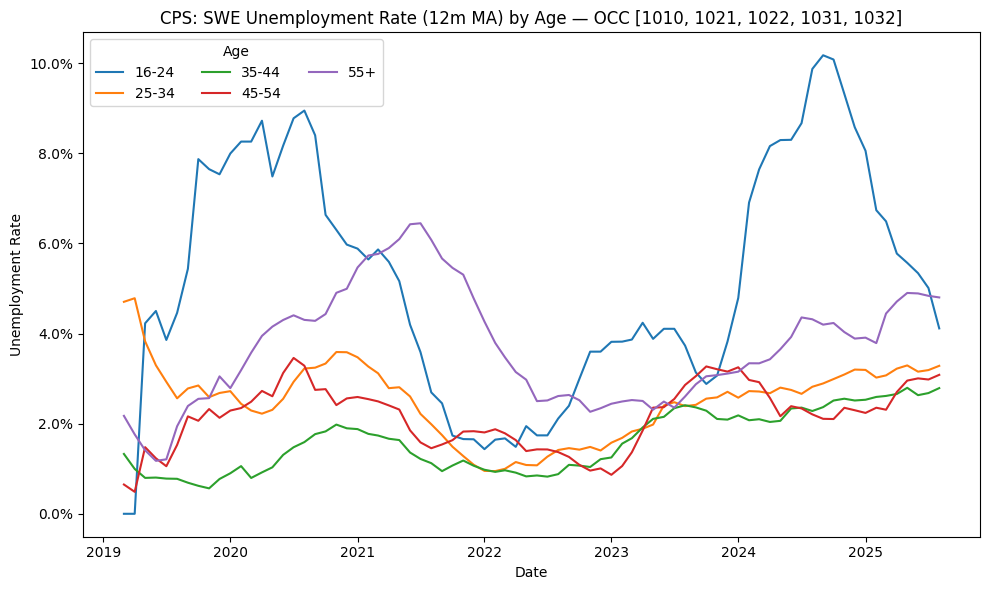

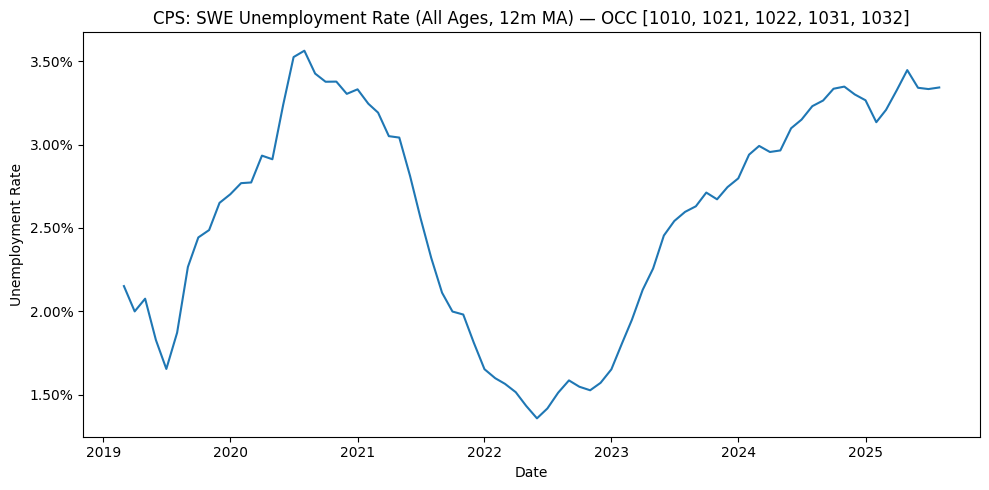

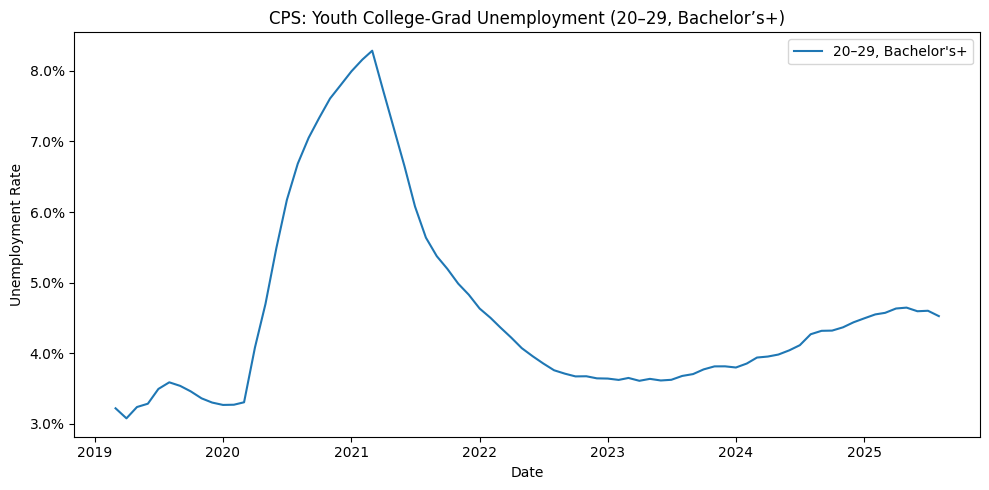


Latest college-grad youth (20–29, BA+):
         date  u_rate_cg  u_rate_cg_ma  n_obs         lf_wt
79 2025-08-01   0.055537      0.045237   2865  1.163597e+07


In [1]:
# --- CPS SWE + College Grad Youth Unemployment (with sample sizes) ---

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

FILE_PATH = "/Users/aidansinclair/Downloads/cps_00001.csv.gz"
OUTPUT_DIR = os.path.expanduser("~/Downloads/cps_swe_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Software OCC codes (CPS 2018+ scheme)
SWE_OCC = [1010, 1021, 1022, 1031, 1032]  # programmers, software devs, QA, web, web/digital

AGE_BINS   = [16, 24, 34, 44, 54, 120]
AGE_LABELS = ["16-24", "25-34", "35-44", "45-54", "55+"]
ROLLING_MONTHS = 12   # set to 1 if you want raw monthly (no smoothing)

def wsum(x, w): return float((x * w).sum())

# ---------- Load ----------
hdr = pd.read_csv(FILE_PATH, nrows=0)
cols = hdr.columns.tolist()
print("Columns in your CPS file:", cols)

needed = {"YEAR","MONTH","WTFINL","EMPSTAT","AGE","OCC","EDUC"}   # <-- now includes EDUC
missing = [c for c in needed if c not in cols]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

usecols = list(needed)
df = pd.read_csv(FILE_PATH, usecols=usecols, low_memory=False)
df["date"] = pd.to_datetime(dict(year=df["YEAR"], month=df["MONTH"], day=1))
df["OCC"]  = pd.to_numeric(df["OCC"], errors="coerce").astype("Int64")

# Labor force flags
is_emp   = df["EMPSTAT"].isin([10,12])
is_unemp = df["EMPSTAT"].isin([20,21,22])
in_lf    = is_emp | is_unemp

# ---------- SWE unemployment by age (same as before) ----------
swe = df[df["OCC"].isin(SWE_OCC) & in_lf].copy()
swe["age_bucket"] = pd.cut(swe["AGE"].clip(lower=16), bins=AGE_BINS, labels=AGE_LABELS, right=True)

grp = swe.groupby(["date","age_bucket"], observed=True)
agg = grp.agg(
    emp_wt   = ("WTFINL", lambda w: wsum(is_emp.loc[w.index].astype(int), w)),
    unemp_wt = ("WTFINL", lambda w: wsum(is_unemp.loc[w.index].astype(int), w)),
    n_obs    = ("WTFINL", "size"),      # unweighted sample size in each cell
    lf_wt    = ("WTFINL", "sum")        # weighted labor-force in cell (emp+unemp)
).reset_index()
agg["lf_wt"] = agg["emp_wt"] + agg["unemp_wt"]
agg = agg[agg["lf_wt"] > 0].copy()
agg["u_rate_swe"] = agg["unemp_wt"] / agg["lf_wt"]
agg = agg.sort_values(["age_bucket","date"])
agg["u_rate_swe_ma"] = agg.groupby("age_bucket", observed=True)["u_rate_swe"] \
                          .transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=3).mean())

# All-ages (optional)
agg_all = (swe.groupby("date", observed=True)
             .agg(emp_wt=("WTFINL", lambda w: wsum(is_emp.loc[w.index].astype(int), w)),
                  unemp_wt=("WTFINL", lambda w: wsum(is_unemp.loc[w.index].astype(int), w)))
             .reset_index())
agg_all["lf_wt"] = agg_all["emp_wt"] + agg_all["unemp_wt"]
agg_all = agg_all[agg_all["lf_wt"] > 0].copy()
agg_all["u_rate_swe"] = agg_all["unemp_wt"] / agg_all["lf_wt"]
agg_all = agg_all.sort_values("date")
agg_all["u_rate_swe_ma"] = agg_all["u_rate_swe"].rolling(ROLLING_MONTHS, min_periods=3).mean()

# ---------- Latest-month sample size context (SWE) ----------
latest = swe["date"].max()
sample_table = (swe[swe["date"]==latest]
                .groupby("age_bucket", observed=True)
                .agg(n_obs=("WTFINL","size"),
                     weighted_lf=("WTFINL","sum"))
               )
print("\nSWE sample size context — latest month:", latest.date())
print(sample_table)

# ---------- College grad youth (20–29, bachelor’s+) ----------
# IPUMS CPS EDUC codes for bachelor's+ are typically 111–125 (Bachelor’s=111, Master’s=114, Prof=115, Doctorate=116).
# To be safe across extracts, we’ll print the unique EDUC codes and then filter >=111.
print("\nUnique EDUC codes present:", sorted(df["EDUC"].dropna().unique().tolist())[:20], "...")

college = df[df["AGE"].between(20,29) & df["EDUC"].ge(111) & in_lf].copy()

agg_cg = (college.groupby("date", observed=True)
          .agg(emp_wt=("WTFINL", lambda w: wsum(is_emp.loc[w.index].astype(int), w)),
               unemp_wt=("WTFINL", lambda w: wsum(is_unemp.loc[w.index].astype(int), w)),
               n_obs=("WTFINL","size"),
               lf_wt=("WTFINL","sum"))
          .reset_index())
agg_cg["lf_wt"] = agg_cg["emp_wt"] + agg_cg["unemp_wt"]
agg_cg = agg_cg[agg_cg["lf_wt"] > 0].copy()
agg_cg["u_rate_cg"] = agg_cg["unemp_wt"] / agg_cg["lf_wt"]
agg_cg = agg_cg.sort_values("date")
agg_cg["u_rate_cg_ma"] = agg_cg["u_rate_cg"].rolling(ROLLING_MONTHS, min_periods=3).mean()

# ---------- Save ----------
agg.to_csv(os.path.join(OUTPUT_DIR, "cps_swe_unemployment_by_age_monthly.csv"), index=False)
agg_all.to_csv(os.path.join(OUTPUT_DIR, "cps_swe_unemployment_allages_monthly.csv"), index=False)
agg_cg.to_csv(os.path.join(OUTPUT_DIR, "cps_collegegrad_20to29.csv"), index=False)

# ---------- Plot helpers ----------
def pct_ax(ax): 
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    return ax

# SWE by age
plt.figure(figsize=(10,6))
for bucket in AGE_LABELS:
    s = agg[agg["age_bucket"]==bucket]
    if not s.empty:
        plt.plot(s["date"], s["u_rate_swe_ma"], label=bucket)
plt.title(f"CPS: SWE Unemployment Rate (12m MA) by Age — OCC {SWE_OCC}")
plt.xlabel("Date"); plt.ylabel("Unemployment Rate")
pct_ax(plt.gca()); plt.legend(ncol=3, title="Age"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cps_swe_unemp_by_age_12m.png"), dpi=160)
plt.show()

# SWE all ages
plt.figure(figsize=(10,5))
plt.plot(agg_all["date"], agg_all["u_rate_swe_ma"])
plt.title(f"CPS: SWE Unemployment Rate (All Ages, 12m MA) — OCC {SWE_OCC}")
plt.xlabel("Date"); plt.ylabel("Unemployment Rate")
pct_ax(plt.gca()); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cps_swe_unemp_allages_12m.png"), dpi=160)
plt.show()

# College-grad youth
plt.figure(figsize=(10,5))
plt.plot(agg_cg["date"], agg_cg["u_rate_cg_ma"], label="20–29, Bachelor's+")
plt.title("CPS: Youth College-Grad Unemployment (20–29, Bachelor’s+)")
plt.xlabel("Date"); plt.ylabel("Unemployment Rate")
pct_ax(plt.gca()); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cps_collegegrad_20to29.png"), dpi=160)
plt.show()

print("\nLatest college-grad youth (20–29, BA+):")
print(agg_cg.tail(1)[["date","u_rate_cg","u_rate_cg_ma","n_obs","lf_wt"]])

In [13]:
# --- (A) College grad youth unemployment (20-29, bachelor’s+) ---
# EDUC codes: bachelor’s or higher = 111+ (depends on your extract coding)
college = df[
    df["AGE"].between(20,29) &
    df["EDUC"].between(111,125) &  # adjust if your IPUMS codebook differs
    in_lf
].copy()

grp_cg = college.groupby("date")
agg_cg = grp_cg.agg(
    emp_wt=("WTFINL", lambda w: wsum(is_emp.loc[w.index].astype(int), w)),
    unemp_wt=("WTFINL", lambda w: wsum(is_unemp.loc[w.index].astype(int), w)),
    n_obs=("WTFINL", "size")   # unweighted sample count
).reset_index()
agg_cg["lf_wt"] = agg_cg["emp_wt"] + agg_cg["unemp_wt"]
agg_cg = agg_cg[agg_cg["lf_wt"] > 0].copy()
agg_cg["u_rate_cg"] = agg_cg["unemp_wt"] / agg_cg["lf_wt"]
agg_cg["u_rate_cg_ma"] = agg_cg["u_rate_cg"].rolling(12, min_periods=3).mean()

# Save + plot
agg_cg.to_csv(os.path.join(OUTPUT_DIR,"cps_collegegrad_20to29.csv"),index=False)

plt.figure(figsize=(10,5))
plt.plot(agg_cg["date"], agg_cg["u_rate_cg_ma"], label="20–29, bachelor’s+")
plt.title("CPS: Youth College Grad Unemployment (20–29, Bachelor’s+)")
plt.ylabel("Unemployment Rate"); plt.xlabel("Date")
percent_axis(plt.gca())
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"cps_collegegrad_20to29.png"),dpi=160)
plt.show()

print("Latest college grad youth unemployment (12m MA):",
      agg_cg.iloc[-1][["date","u_rate_cg_ma","n_obs"]])

KeyError: 'EDUC'